# Task 6: License Dataset Analysis

Action: Load and explore the Ontario elevator license dataset to prepare it for use in future modules.

## Setup: Import libraries and load license.csv
Use pandas to load data/license.csv into a DataFrame; display shape and head for context.

In [7]:
import pandas as pd

license_df = pd.read_csv("../data/license.csv")

license_df.shape

(45383, 11)

In [8]:
license_df.head(5)

,ElevatingDevicesNumber,LocationoftheElevatingDevice,ElevatingDevicesLicenseNumber,LICENSESTATUS,LICENSEEXPIRYDATE,LICENSEHOLDER,LICENSEHOLDERACCOUNTNUMBER,LICENSEHOLDERADDRESS,BILLINGCUSTOMER,BILLINGADDRESS,BILLINGACCOUNT
0,10,111 WELLESLEY ST W TORONTO M7A 1A2 ON CA,EDLIC-000010,ACTIVE,28-Apr-17,LEGISLATIVE ASSEMBLY OF ONTARIO ATTN: JOHN ED...,data redacted,99 WELLESLEY ST W WHITNEY BLOCK ROOM 2540 TOR...,LEGISLATIVE ASSEMBLY OF ONTARIO ATTN: JOHN ED...,99 WELLESLEY ST W WHITNEY BLOCK ROOM 2540 TOR...,data redacted
1,100,1804 HIGHWAY 2 E BROCKVILLE K6V 5T1 ON CA,170719,BY REQUEST,12-Dec-14,INFRASTRUCTURE ONTARIO AND LANDS CORPORATION,data redacted,18 KING ST E TORONTO ON M5C 1C4 CA,CB RICHARD ELLIS GLOBAL CORPORATE SERVICES,333 PRESTON ST 7TH FLR PRESTON SQUARE TOWER 1 ...,data redacted
2,10047,162 PEMBROKE ST W PEMBROKE K8A 5M8 ON CA,EDLIC-010047,BY REQUEST,15-Mar-08,PROFAC MANAGEMENT GROUP LTD,data redacted,304 THE EAST MALL P.O. # 653058-Y3-20610 TORON...,PROFAC MANAGEMENT GROUP LTD,304 THE EAST MALL P.O. # 653058-Y3-20610 TORON...,data redacted
3,10054,541 SUSSEX DR OTTAWA K1N 6Z6 ON CA,EDLIC-010054,BY REQUEST,01-Oct-05,DEPARTMENT OF PUBLIC WORKS & GOVERNMENT SERVIC...,data redacted,4900 YONGE ST 11TH FLOOR TORONTO ON M2N 6A6 CA,DEPARTMENT OF PUBLIC WORKS & GOVERNMENT SERVIC...,"4900 YONGE ST 11TH FLOOR TORONTO, ON, M2N 6A6, CA",data redacted
4,1009,404 MAIN ST WOODSTOCK N4S 7X5 ON CA,EDLIC-001009,ACTIVE,15-Jul-17,AGRIBRANDS PURINA CANADA INC,data redacted,404 MAIN ST PO BOX 250 WOODSTOCK ON N4S 7X5 CA,AGRIBRANDS PURINA CANADA INC,"404 MAIN ST PO BOX 250 WOODSTOCK, ON, N4S 7X5, CA",data redacted


## Task 6
 (a) Identify unique elevator identifier with uniqueness checks
Inspect candidate ID-like columns, compute distinct counts and uniqueness; select the best identifier and justify with code outputs.

In [9]:
pd.DataFrame({"column": license_df.columns, "dtype": license_df.dtypes.astype(str)})

,column,dtype
ElevatingDevicesNumber,ElevatingDevicesNumber,int64
LocationoftheElevatingDevice,LocationoftheElevatingDevice,str
ElevatingDevicesLicenseNumber,ElevatingDevicesLicenseNumber,str
LICENSESTATUS,LICENSESTATUS,str
LICENSEEXPIRYDATE,LICENSEEXPIRYDATE,str
LICENSEHOLDER,LICENSEHOLDER,str
LICENSEHOLDERACCOUNTNUMBER,LICENSEHOLDERACCOUNTNUMBER,str
LICENSEHOLDERADDRESS,LICENSEHOLDERADDRESS,str
BILLINGCUSTOMER,BILLINGCUSTOMER,str
BILLINGADDRESS,BILLINGADDRESS,str


In [10]:
candidate_cols = [
    col
    for col in license_df.columns
    if any(token in col.lower() for token in ["id", "number", "license", "licence", "device", "elevator"])
]

uniqueness = []
for col in candidate_cols:
    series = license_df[col]
    uniqueness.append(
        {
            "column": col,
            "non_null_count": int(series.notna().sum()),
            "unique_count": int(series.nunique(dropna=True)),
            "is_unique": bool(series.is_unique),
        }
    )

pd.DataFrame(uniqueness).sort_values("unique_count", ascending=False)

,column,non_null_count,unique_count,is_unique
0,ElevatingDevicesNumber,45383,45383,True
2,ElevatingDevicesLicenseNumber,45383,45383,True
1,LocationoftheElevatingDevice,45340,23442,False
5,LICENSEHOLDER,45383,16363,False
7,LICENSEHOLDERADDRESS,45383,13276,False
4,LICENSEEXPIRYDATE,45383,1118,False
3,LICENSESTATUS,45383,11,False
6,LICENSEHOLDERACCOUNTNUMBER,45383,1,False


**Justification:**
Based on the uniqueness checks above, two columns are candidates because they are unique. We will use `ElevatingDevicesNumber` as the identifier for this analysis since it is the field that matches and links to other tables in the project. That makes it the most reliable key for cross‑dataset joins in Module 2.

## (b) Extract country and province from location column
The dataset contains a location column that combines geographic information. Extract the country and state/province into two new columns using a pandas string method and identify where the majority of elevators are located.

**Answer:** The majority of elevators are located in Ontario, Canada.

In [11]:
license_df[["province", "country"]] = license_df["LocationoftheElevatingDevice"].str.extract(
    r"\s([A-Z]{2})\s+([A-Z]{2})\s*$"
)

print(license_df["country"].value_counts(dropna=False))
print()
print(license_df["province"].value_counts(dropna=False))
print()

majority_country = license_df["country"].value_counts().idxmax()
majority_province = license_df["province"].value_counts().idxmax()
f"Majority location: {majority_province}, {majority_country}"

country
CA     45340
NaN       43
Name: count, dtype: int64

province
ON     45340
NaN       43
Name: count, dtype: int64



'Majority location: ON, CA'

**Answer:** The majority of elevators are located in Ontario, Canada.

## (c) Filter dataset to operationally active elevators
Examine all values in `LICENSESTATUS` using `value_counts()`. Keep only the statuses that represent elevators currently in legal operation, overwrite the DataFrame, and justify every keep/remove decision by explaining what each status means operationally.

In [12]:
print(license_df["LICENSESTATUS"].value_counts(dropna=False))

KEEP = {"ACTIVE", "PENDING_RENEWAL"}

license_df = license_df[license_df["LICENSESTATUS"].isin(KEEP)].reset_index(drop=True)

print(f"\nRows after filtering: {len(license_df):,} (removed {45_383 - len(license_df):,} rows)")

LICENSESTATUS
ACTIVE                   42665
CANCELLED_NOT_RENEWED     1163
PENDING_RENEWAL            632
TERMINATED                 475
BY REQUEST                 337
EXPIRED                     68
HOLD_TSD                    24
TERMINATED DECEASED          6
CANCELLED_BY_CUST_REQ        6
ENTERED                      4
CANCELLED                    3
Name: count, dtype: int64

Rows after filtering: 43,297 (removed 2,086 rows)


**Justification:**

I kept only statuses that clearly mean “operating now” and removed everything cancelled, terminated, expired, or incomplete so Module 2 focuses on active elevators.

**Kept:**
- `ACTIVE` (42,665): valid and operating.
- `PENDING_RENEWAL` (632): still operating while renewal is processed.

**Removed:** all other statuses because they indicate non‑operation (cancelled, terminated, expired, on hold, or incomplete).

## (d) Re-verify identifier uniqueness after filtering
After applying the status filter, confirm that the identifier selected in (a) is still unique across the filtered DataFrame. If uniqueness has been lost, explain why and what that implies for merges in Module 2.

In [13]:
id_col = "ElevatingDevicesNumber"

is_unique = license_df[id_col].is_unique
n_duplicates = license_df[id_col].duplicated().sum()

print(f"Column       : {id_col}")
print(f"Rows         : {len(license_df):,}")
print(f"Unique values: {license_df[id_col].nunique():,}")
print(f"Duplicates   : {n_duplicates}")
print(f"Is unique    : {is_unique}")

Column       : ElevatingDevicesNumber
Rows         : 43,297
Unique values: 43,297
Duplicates   : 0
Is unique    : True


**Verification result:**

`ElevatingDevicesNumber` remains unique after filtering — every row in the filtered DataFrame maps to exactly one elevator, with zero duplicates.


Filtering by `LICENSESTATUS` removes rows but never adds them, so it can only reduce the number of duplicate keys, not introduce new ones. 



## (e) License expiration timeline
Create a visualization that shows how license expirations are distributed over time. The time axis must be derived entirely from the data.

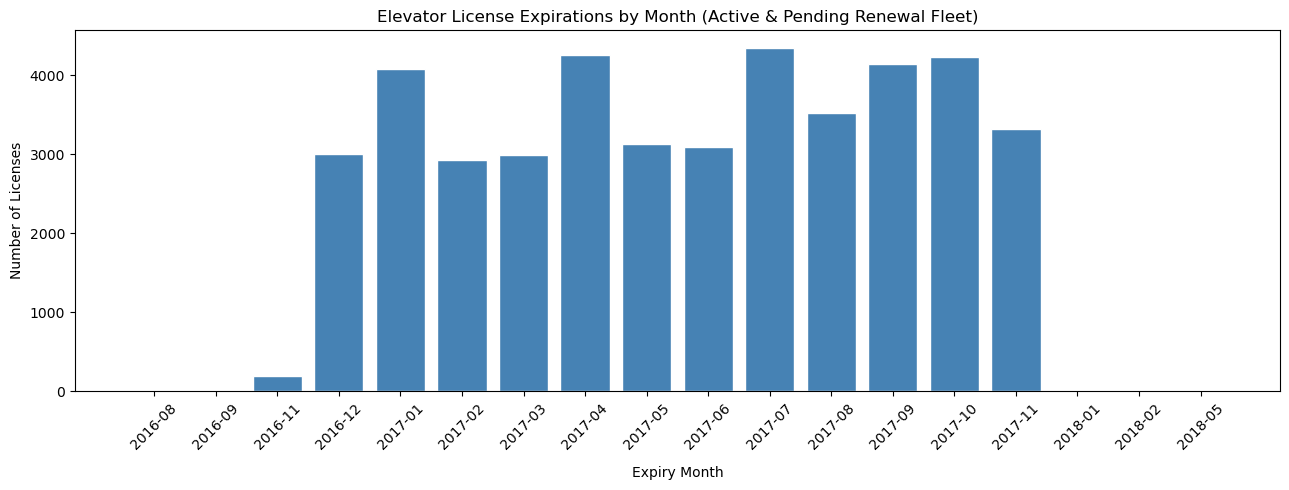

In [14]:
import matplotlib.pyplot as plt

expiry = pd.to_datetime(license_df["LICENSEEXPIRYDATE"], format="%d-%b-%y")
monthly_counts = expiry.dt.to_period("M").value_counts().sort_index()

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(monthly_counts.index.astype(str), monthly_counts.values, color="steelblue", edgecolor="white")

ax.set_xlabel("Expiry Month", labelpad=10)
ax.set_ylabel("Number of Licenses")
ax.set_title("Elevator License Expirations by Month (Active & Pending Renewal Fleet)")
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## Extra-Mile 2: Two-Column Visualization — License Status by Expiry Month

Using the filtered license DataFrame, create a grouped bar chart that shows the count of elevators by both `LICENSESTATUS` and expiry month. Use `groupby` on two columns and `unstack()` to reshape before plotting.

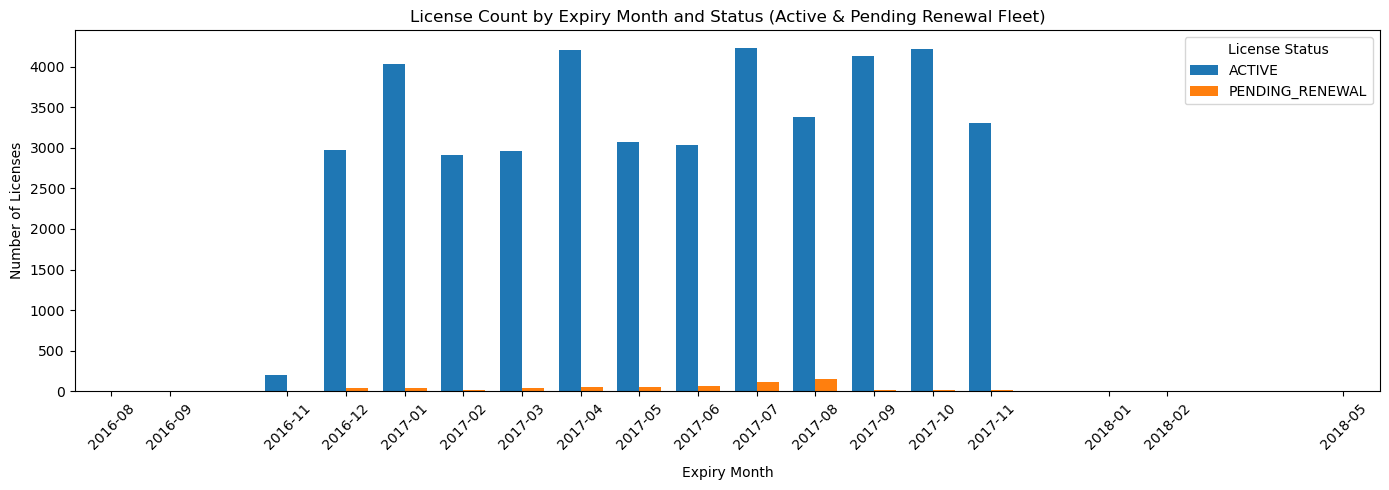

In [15]:
license_df["expiry_month"] = pd.to_datetime(
    license_df["LICENSEEXPIRYDATE"], format="%d-%b-%y"
).dt.to_period("M")

grouped = (
    license_df.groupby(["expiry_month", "LICENSESTATUS"])
    .size()
    .unstack("LICENSESTATUS")
    .fillna(0)
    .astype(int)
)

ax = grouped.plot(kind="bar", figsize=(14, 5), width=0.75)

ax.set_xlabel("Expiry Month", labelpad=10)
ax.set_ylabel("Number of Licenses")
ax.set_title("License Count by Expiry Month and Status (Active & Pending Renewal Fleet)")
ax.legend(title="License Status")
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

**Pattern analysis:**

This chart shows counts by `LICENSESTATUS` and `expiry_month`, so you can see how status changes across time instead of only totals. `PENDING_RENEWAL` is concentrated in mid‑2017 (notably July–August), while `ACTIVE` is spread more evenly across months. That timing pattern is not visible in the single‑column charts, which only show overall totals. It suggests renewal activity is seasonal rather than uniform.